In [15]:
import pandas as pd
import sqlite3
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np

Parsing SQLite tables to cleaned dataframes

In [2]:
dbconn = sqlite3.connect('location.db')
tables = list(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", dbconn)['name'])

In [3]:
location_dfs = []

for table in tables:
    table_name = "\'" + table + "\'"
    
    sql_query = """
    SELECT DISTINCT MAX(F.timestamp) AS max_timestamp, F.stopId, G.tripId
    FROM (
        SELECT *
        FROM (
            SELECT MAX(timestamp) AS max_timestamp, stopId, [trip.tripId] AS tripId FROM %s
            WHERE [trip.routeId] = 6641 AND [trip.directionId] = 1 AND (stopId = 11606 OR stopId = 12483)
            GROUP BY tripId, stopId
            )
        GROUP BY tripId
        HAVING COUNT(*) = 2
        ) G
    INNER JOIN %s F ON F.[trip.tripId] = G.tripId
    WHERE F.stopId = 11606 OR F.stopId = 12483
    GROUP BY G.tripId, F.stopId
    ORDER BY tripId
    """ % (table_name, table_name)
    
    location_dfs.append(pd.read_sql_query(sql_query, dbconn))

In [4]:
location_dfs[0].head()

,max_timestamp,stopId,tripId
0,1776351675,11606,14898260
1,1776354503,12483,14898260
2,1776351851,11606,14898261
3,1776354509,12483,14898261
4,1776352088,11606,14898262


Cleaning & transforming timestamps into relevant delta times

In [5]:
delta_time_dfs = []

for df in location_dfs:
    delta_df = df
    
    delta_df['start_time'] = pd.to_datetime(delta_df['max_timestamp'], unit = 's', errors = 'coerce')
    delta_df['ending_time'] = delta_df.groupby('tripId')['start_time'].shift(-1)
    delta_df['delta_time'] = (delta_df['ending_time'] - delta_df['start_time'])
    delta_df = delta_df[pd.notnull(delta_df['delta_time'])]
    delta_df['delta_time_min'] = delta_df['delta_time'].dt.total_seconds().div(60)

    cleaned_df = delta_df[['tripId', 'delta_time_min']]
        
    delta_time_dfs.append(cleaned_df)

In [6]:
delta_time_dfs[0].head()

,tripId,delta_time_min
0,14898260,47.133333
2,14898261,44.300000
4,14898262,43.266667
6,14898263,40.666667
8,14898264,46.466667


### Hypothesis testing: Is the average 99 bus duration greater than the expected average of 41.3 minutes?

We conduct a one-sample t-test at a significance level of 0.05.

Randomly sampling from each dataframe for independence

In [7]:
samples = []

for df in delta_time_dfs:
    sample = df.sample(n=6)
    samples.append(sample)

sampled_df = pd.concat(samples)
sampled_df.head()

,tripId,delta_time_min
26,14898283,43.550000
34,14898287,46.883333
8,14898264,46.466667
10,14898265,43.483333
56,14898314,40.683333


In [8]:
h_0 = 41.3
t_stat, p_value = stats.ttest_1samp(sampled_df['delta_time_min'], h_0)
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -3.6673
P-value: 0.0008


Visualization

Text(0, 0.5, 'Time (min)')

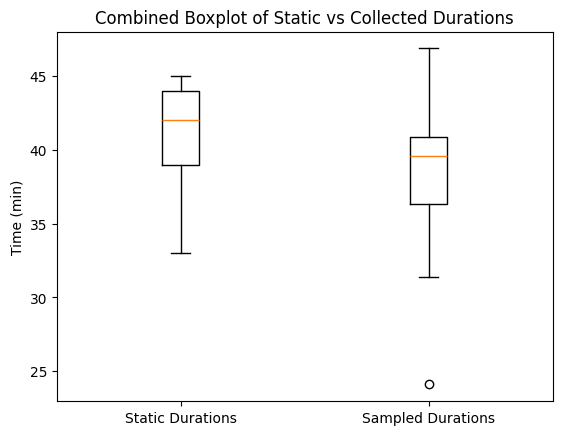

In [9]:
static_durations = pd.read_csv('../static_durations.csv')
plt.boxplot([static_durations['delta_time_min'], sampled_df['delta_time_min']], tick_labels = ["Static Durations", "Sampled Durations"])
plt.title('Combined Boxplot of Static vs Collected Durations')
plt.ylabel('Time (min)')

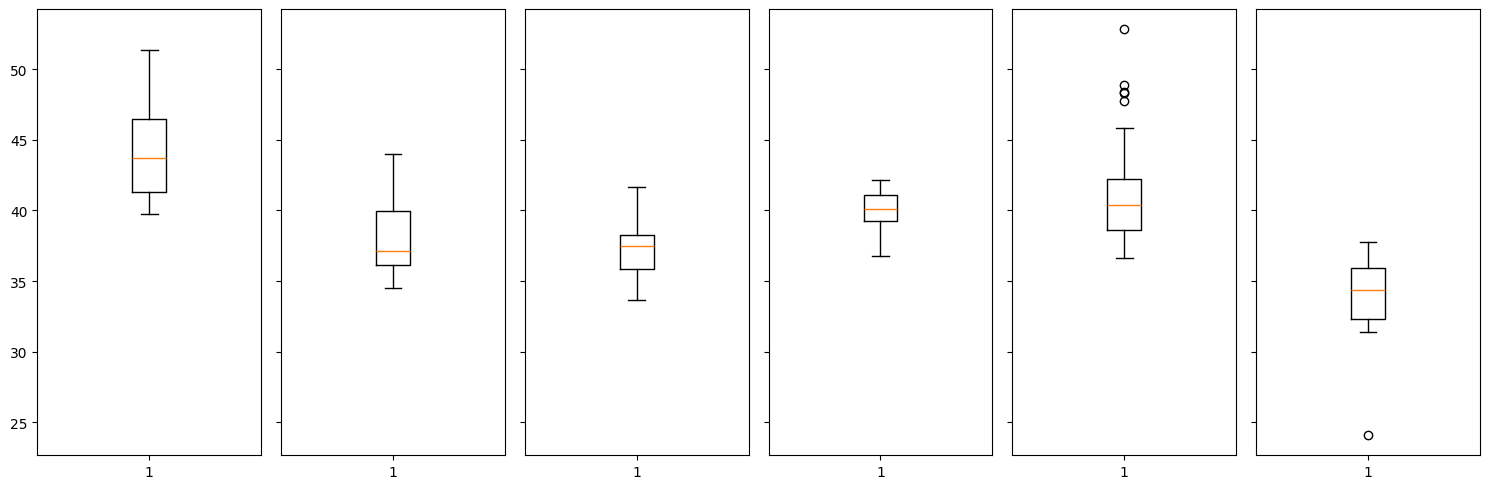

In [10]:
fig, ax = plt.subplots(ncols=6, sharey=True, figsize = (15,5))
index = 1
for df in delta_time_dfs:
    array = df['delta_time_min']
    plt.subplot(1, 6, index)
    plt.boxplot(array)
    
    index = index + 1

plt.tight_layout()

In [27]:
isolated_arrays = []

for df in delta_time_dfs:
    isolated_array = df['delta_time_min']
    isolated_arrays.append(isolated_array)

f_stat, p_value = stats.f_oneway(*isolated_arrays)

print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))


F-statistic: 25.5137
P-value: 0.0
